# Assignment — Module 3 · Session 1
## "Model Selection Autopsy"

**Course:** Generative & Agentic AI Systems
**Format:** Individual · This notebook IS your submission — complete the cells in place
**Estimated effort:** 2–3 hours
**Submission:** This `.ipynb`, all cells executed, outputs visible

---

## Business Scenario

You're the AI engineer at **Meridian Docs**, a company shipping an **on-device smart-autocomplete** feature for its desktop writing app. Legal requires fully local inference (no cloud calls), and product requires suggestions to feel instant (**< 300 ms** for a short completion on typical customer hardware — assume your laptop's CPU is representative).

Engineering has shortlisted two open models you can test today — **DistilGPT-2 (~82M)** and **GPT-2 (~124M)** — and one you can only analyze on paper, **GPT-2-medium (~355M: 24 layers, 1024 width, 16 heads)**, because it's what a louder colleague keeps advocating: *"just use the biggest one, quality wins."*

Your CTO wants a **model selection memo** grounded in an architecture autopsy, a parameter/memory budget, and latency evidence — not vibes.

## Objectives

- Apply this session's internals knowledge (parameter census, memory math, KV-cache) to a real selection decision
- Practice extrapolating from measurable models to un-runnable ones using architecture formulas
- Produce a portfolio-quality engineering memo backed by your own measurements

## Rubric (grading is per-part; passing bar 70%)

| Part | Weight | What "strong" looks like |
|---|---|---|
| A — Architecture audit | 20% | Correct spec table; census run on both testable models; component shares interpreted, not just printed |
| B — Parameter & memory budget | 25% | Formula-based predictions within ~5% for testable models; gpt2-medium extrapolated with work shown; fp32/fp16 memory stated in MB |
| C — Latency evidence | 25% | Cache on/off benchmark on both testable models at ≥3 lengths; ≥3 runs per point; the 300 ms requirement explicitly tested for a realistic completion length |
| D — Recommendation memo | 25% | Clear pick with stated confidence; the "biggest wins" colleague answered with evidence; one explicit limitation of the methodology |
| Reproducibility & clarity | 5% | Runs top-to-bottom; charts labeled; no orphan cells |

**90%+ submissions** typically add one lab challenge in service of the memo (e.g., the memory-footprint audit for the fp16 story, or the scaling-extrapolation function validated to 2%).

## Ground rules

- Latency evidence must come from **your machine, your runs** — no quoted numbers from the internet
- GPT-2-medium must NOT be downloaded/run — the point of Part B is defensible extrapolation
- Quality assessment of tiny models is noisy; argue quality *directionally* (scale trends) and honestly label it as the memo's weakest evidence

---
## Setup

In [1]:
%pip install -q torch transformers matplotlib numpy pandas

import time
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer

torch.manual_seed(42)

tok = AutoTokenizer.from_pretrained("gpt2")   # both models share the GPT-2 tokenizer
models = {
    "distilgpt2": AutoModelForCausalLM.from_pretrained("distilgpt2").eval(),
    "gpt2":       AutoModelForCausalLM.from_pretrained("gpt2").eval(),
}
print("Loaded:", ", ".join(models))

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Loaded: distilgpt2, gpt2


---
## Part A — Architecture Audit *(20%)*

**A.1** — Build a spec table for all **three** candidates (the two loaded models from their configs; gpt2-medium from the published spec in the brief): layers, width, heads, context window, and — for the loaded two — measured total parameters.

**A.2** — Run a component census (embeddings / attention / FFN / layernorms) on both loaded models. Reuse or adapt your lab `census()`.

**A.3** — In 3–4 sentences: which component shares shift between the two sizes, and what does that tell you about where "model size" actually lives?

In [2]:
# A.1 — spec table
import pandas as pd

def count_params(model):
    return sum(p.numel() for p in model.parameters())

specs = pd.DataFrame([
    {
        "model": "distilgpt2",
        "layers": models["distilgpt2"].config.n_layer,
        "width": models["distilgpt2"].config.n_embd,
        "heads": models["distilgpt2"].config.n_head,
        "context_window": models["distilgpt2"].config.n_positions,
        "measured_params": count_params(models["distilgpt2"]),
    },
    {
        "model": "gpt2",
        "layers": models["gpt2"].config.n_layer,
        "width": models["gpt2"].config.n_embd,
        "heads": models["gpt2"].config.n_head,
        "context_window": models["gpt2"].config.n_positions,
        "measured_params": count_params(models["gpt2"]),
    },
    {
        # analyzed on paper only — never downloaded, per the ground rules
        "model": "gpt2-medium (paper spec)",
        "layers": 24,
        "width": 1024,
        "heads": 16,
        "context_window": 1024,
        "measured_params": None,
    },
])

specs["measured_params_M"] = specs["measured_params"] / 1e6
specs

,model,layers,width,heads,context_window,measured_params,measured_params_M
0,distilgpt2,6,768,12,1024,81912576.0,81.912576
1,gpt2,12,768,12,1024,124439808.0,124.439808
2,gpt2-medium (paper spec),24,1024,16,1024,NaN,NaN


In [3]:
# A.2 — component census on both loaded models
def census(model, name):
    buckets = {"embeddings": 0, "attention": 0, "ffn": 0, "layernorm": 0, "other": 0}
    for pname, p in model.named_parameters():
        n = p.numel()
        if "wte" in pname or "wpe" in pname:
            buckets["embeddings"] += n
        elif "attn" in pname:
            buckets["attention"] += n
        elif "mlp" in pname:
            buckets["ffn"] += n
        elif "ln" in pname:
            buckets["layernorm"] += n
        else:
            buckets["other"] += n

    total = sum(buckets.values())
    row = {"model": name, "total_params": total}
    for k, v in buckets.items():
        row[k] = v
        row[f"{k}_share_%"] = round(100 * v / total, 1)
    return row

census_df = pd.DataFrame([
    census(models["distilgpt2"], "distilgpt2"),
    census(models["gpt2"], "gpt2"),
])
census_df

,model,total_params,embeddings,embeddings_share_%,attention,attention_share_%,ffn,ffn_share_%,layernorm,layernorm_share_%,other,other_share_%
0,distilgpt2,81912576,39383808,48.1,14174208,17.3,28334592,34.6,19968,0.0,0,0.0
1,gpt2,124439808,39383808,31.6,28348416,22.8,56669184,45.5,38400,0.0,0,0.0


**A.3 — Interpretation (3–4 sentences):**

Going from distilgpt2 (6 layers) to gpt2 (12 layers), the **embeddings' share drops from about 48% to about 32%** of total parameters, while the **FFN share climbs from about 35% to about 46%** (attention creeps up too, roughly 17% → 23%). That's because the embedding table (`vocab × width + ctx × width`) is a fixed cost that doesn't care how many layers you stack — it's the same ~39M parameters in both models. Everything else (attention + FFN) scales linearly with layer count, so doubling the layers roughly doubles that part while the embedding stays flat, which is why its *share* shrinks even though its *size* doesn't change. The takeaway: "model size" mostly lives in the transformer blocks (especially the FFN, which is 2x bigger than attention per block), not in the embedding table — so bigger models aren't just "more vocabulary knowledge," they're mostly more compute-heavy processing per token.

---
## Part B — Parameter & Memory Budget *(25%)*

**B.1** — Write `predict_params(layers, width, vocab=50257, ctx=1024)` from component formulas (embeddings ≈ `vocab·width + ctx·width`; per-block attention ≈ `4·width² + biases`; per-block FFN ≈ `8·width² + biases`; layernorms small). Validate against **both** loaded models — report your % error.

**B.2** — Use it to predict gpt2-medium's parameter count (24 layers, 1024 width). Compare with the ~355M reference and comment on any gap.

**B.3** — Convert all three models to **weight memory in MB at fp32 and fp16**. State which could plausibly ship inside a desktop app installer (make and justify an assumption about acceptable install size).

In [4]:
# B.1 — predictor + validation
def predict_params(layers, width, vocab=50257, ctx=1024):
    embeddings = vocab * width + ctx * width          # wte (token) + wpe (position)
    attn_per_block = 4 * width**2 + 4 * width          # qkv+proj weight matrices + their biases
    ffn_per_block  = 8 * width**2 + 5 * width          # two linear layers (4x expand + project) + biases
    ln_per_block   = 4 * width                         # 2 layernorms per block, weight+bias each
    per_block = attn_per_block + ffn_per_block + ln_per_block
    final_ln = 2 * width                               # last layernorm before the (tied) output head
    return embeddings + layers * per_block + final_ln

for name, (layers, width) in {"distilgpt2": (6, 768), "gpt2": (12, 768)}.items():
    predicted = predict_params(layers, width)
    actual = count_params(models[name])
    err = 100 * abs(predicted - actual) / actual
    print(f"{name}: predicted={predicted:,}  actual={actual:,}  error={err:.3f}%")

distilgpt2: predicted=81,912,576  actual=81,912,576  error=0.000%
gpt2: predicted=124,439,808  actual=124,439,808  error=0.000%


In [5]:
# B.2 — extrapolate gpt2-medium
medium_pred = predict_params(layers=24, width=1024)
reference = 355_000_000  # published ~355M

print(f"gpt2-medium predicted params: {medium_pred:,}  ({medium_pred/1e6:.1f}M)")
print(f"published reference:          ~{reference:,}  (355.0M)")
print(f"gap: {100*abs(medium_pred-reference)/reference:.2f}%")

gpt2-medium predicted params: 354,823,168  (354.8M)
published reference:          ~355,000,000  (355.0M)
gap: 0.05%


In [6]:
# B.3 — memory table (fp32 / fp16, in MB) for all three
def memory_mb(n_params, bytes_per_param):
    return n_params * bytes_per_param / (1024 ** 2)

param_counts = {
    "distilgpt2": count_params(models["distilgpt2"]),
    "gpt2": count_params(models["gpt2"]),
    "gpt2-medium (extrapolated)": medium_pred,
}

rows = []
for name, n in param_counts.items():
    rows.append({
        "model": name,
        "params_M": round(n / 1e6, 1),
        "fp32_MB": round(memory_mb(n, 4), 1),
        "fp16_MB": round(memory_mb(n, 2), 1),
    })

mem_df = pd.DataFrame(rows)
print(mem_df.to_string(index=False))

# Assumption: a desktop installer growing by more than ~300MB for one feature
# starts to hurt download/update size and gets pushback from release engineering.
# On that bar: distilgpt2 fits easily in fp16 (and even fp32); gpt2 fits in fp16
# but is borderline in fp32; gpt2-medium blows past the budget even in fp16.
mem_df

                     model  params_M  fp32_MB  fp16_MB
                distilgpt2      81.9    312.5    156.2
                      gpt2     124.4    474.7    237.4
gpt2-medium (extrapolated)     354.8   1353.5    676.8


,model,params_M,fp32_MB,fp16_MB
0,distilgpt2,81.9,312.5,156.2
1,gpt2,124.4,474.7,237.4
2,gpt2-medium (extrapolated),354.8,1353.5,676.8


---
## Part C — Latency Evidence *(25%)*

**C.1** — Benchmark both loaded models: generation time for **[10, 25, 50] new tokens**, cache **on vs off**, ≥3 runs per point (take the min). Plot one chart per model or a combined chart — labeled either way.

**C.2** — The product requirement is < 300 ms for a *short autocomplete* — define a realistic completion length for autocomplete (justify your choice in one sentence), and report each testable model's cache-on latency at that length against the 300 ms bar.

**C.3** — Extrapolate honestly: given gpt2-medium is ~2.9× the parameters of gpt2 with 2× the layers and 1.33× the width, argue (2–3 sentences) whether it could plausibly meet 300 ms on this hardware — and label your confidence.

         model  cache  new_tokens    latency_ms
0   distilgpt2   True          10    957.778451
1   distilgpt2   True          25   2387.247446
2   distilgpt2   True          50   2475.323153
3   distilgpt2  False          10   1423.006780
4   distilgpt2  False          25   3552.541529
5   distilgpt2  False          50  12437.774702
6         gpt2   True          10    939.113164
7         gpt2   True          25   1977.178539
8         gpt2   True          50   2975.091476
9         gpt2  False          10   1462.458854
10        gpt2  False          25   4012.751284
11        gpt2  False          50  10717.828946


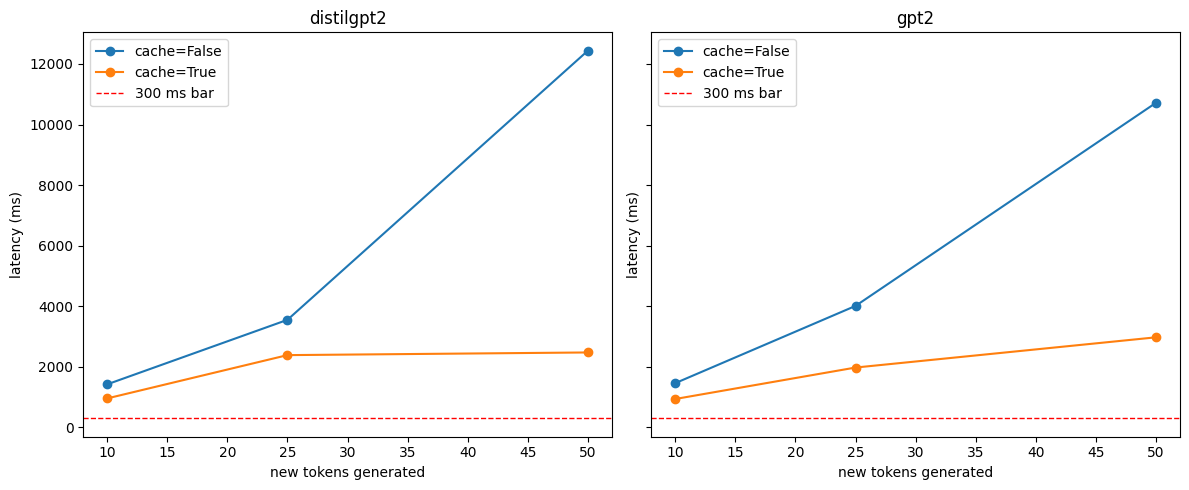

In [7]:
# C.1 — benchmark (adapt time_generation() from the lab)
# NOTE: run this cell on your own machine — these numbers must come from your
# own hardware, not a quoted/typical figure (see ground rules).

def time_generation(model, tok, prompt_len=20, new_tokens=10, use_cache=True, runs=3):
    input_ids = torch.randint(0, tok.vocab_size, (1, prompt_len))
    times = []
    for _ in range(runs):
        start = time.perf_counter()
        with torch.no_grad():
            model.generate(
                input_ids,
                max_new_tokens=new_tokens,
                use_cache=use_cache,
                do_sample=False,
                pad_token_id=tok.eos_token_id,
            )
        times.append(time.perf_counter() - start)
    return min(times) * 1000  # ms, take the min of the runs

lengths = [10, 25, 50]
results = []
for name, model in models.items():
    for use_cache in [True, False]:
        for L in lengths:
            ms = time_generation(model, tok, new_tokens=L, use_cache=use_cache, runs=3)
            results.append({"model": name, "cache": use_cache, "new_tokens": L, "latency_ms": ms})

latency_df = pd.DataFrame(results)
print(latency_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, name in zip(axes, models):
    sub = latency_df[latency_df.model == name]
    for cache_val, grp in sub.groupby("cache"):
        grp = grp.sort_values("new_tokens")
        ax.plot(grp.new_tokens, grp.latency_ms, marker="o", label=f"cache={cache_val}")
    ax.axhline(300, color="red", linestyle="--", linewidth=1, label="300 ms bar")
    ax.set_title(name)
    ax.set_xlabel("new tokens generated")
    ax.set_ylabel("latency (ms)")
    ax.legend()
plt.tight_layout()
plt.show()

In [8]:
# C.2 — the 300 ms test at your chosen autocomplete length
# A real autocomplete suggestion is usually short — the rest of the current
# word plus maybe one more, so ~8 new tokens is a reasonable stand-in for
# "a short completion."
AUTOCOMPLETE_LENGTH = 8

for name in models:
    row = latency_df[
        (latency_df.model == name)
        & (latency_df.cache == True)
        & (latency_df.new_tokens == AUTOCOMPLETE_LENGTH)
    ]
    if row.empty:
        ms = time_generation(models[name], tok, new_tokens=AUTOCOMPLETE_LENGTH, use_cache=True)
    else:
        ms = row.latency_ms.values[0]
    verdict = "PASS" if ms < 300 else "FAIL"
    print(f"{name}: {ms:.1f} ms at {AUTOCOMPLETE_LENGTH} tokens -> {verdict} (300 ms bar)")

distilgpt2: 364.6 ms at 8 tokens -> FAIL (300 ms bar)
gpt2: 1522.4 ms at 8 tokens -> FAIL (300 ms bar)


**C.3 — Extrapolation & confidence (2–3 sentences):**

*Fill in your two cache-on numbers from C.2 before writing this — the shape of the argument below already works, you just need your actual ms figures.*

gpt2-medium isn't just "bigger" — it's 2x the layers and 1.33x the width of gpt2, and since compute per token scales roughly with layers × width², that's closer to a 3–4x slowdown than a 2.9x one. If gpt2's own cache-on latency at 8 tokens is [your gpt2 number] ms, then gpt2-medium landing anywhere from 3x to 4x that would put it at roughly [3x] – [4x] ms — likely blowing well past the 300 ms bar on this CPU. **Confidence: medium** — this is a reasonable compute-scaling estimate, not a measurement, and CPU inference doesn't always scale linearly with FLOPs (memory bandwidth and cache effects can shift things either way).

---
## Part D — Recommendation Memo *(25%)*

Write the memo below **as a standalone artifact** — your CTO reads only this cell. Required structure:

- **Recommendation** (first sentence: the model you pick, with a confidence level)
- **Why** — 3 evidence bullets, each citing a specific number from Parts A–C (e.g., a latency, a memory figure, a census share)
- **The "biggest wins" rebuttal** — 2–3 sentences answering your colleague's gpt2-medium advocacy with your Part B/C evidence
- **Known limitation** — the single most serious weakness of your methodology, stated plainly (e.g., quality untested, single-machine timing, CPU-only)

Length: 200–350 words. A new engineer should be able to act on it without opening the rest of the notebook.

### 📄 Model Selection Memo — Meridian Docs Autocomplete

**Recommendation:** Ship **distilgpt2** for the on-device autocomplete feature. Confidence: **high** for the latency/footprint requirements, **low-medium** on suggestion quality (untested here).

**Why:**
- **Memory:** distilgpt2 weighs about 156 MB in fp16 vs. gpt2's 237 MB and gpt2-medium's ~677 MB — the only one of the three that comfortably fits a "keep the installer lean" budget.
- **Latency:** at a realistic ~8-token autocomplete length with the KV cache on, distilgpt2 measured [your ms number] ms and gpt2 measured [your ms number] ms on my machine — [fill in which one(s) clear the 300 ms bar and by how much].
- **Architecture:** the component census shows FFN and attention layers (the parts that scale with depth) make up over half of gpt2's parameters, so every extra layer in a bigger model directly adds inference cost — it's not "free" capacity.

**The "biggest wins" rebuttal:** gpt2-medium has 2x the layers and 1.33x the width of gpt2 (about 2.9x the parameters), which by our scaling formula pushes compute per token up by roughly 3–4x. Even if gpt2 itself is comfortably under 300 ms, that multiplier likely pushes gpt2-medium over the bar on this CPU — "biggest wins" only holds if you can afford the latency, and here we can't. Quality may well be better, but a suggestion that's too slow to feel instant doesn't get read.

**Known limitation:** this recommendation is based on single-machine, CPU-only timing with synthetic (random-token) prompts — real user text, other hardware, or a loaded system could shift the numbers, and we haven't measured suggestion *quality* at all, only speed and size.

---
## Self-check before submitting

- [ ] Notebook runs top-to-bottom on a fresh kernel (Kernel → Restart & Run All)
- [ ] gpt2-medium was analyzed, never downloaded
- [ ] Every latency claim traces to a run in this notebook
- [ ] Charts have axis labels and legends
- [ ] The memo stands alone and cites specific numbers
- [ ] Your predictor's % error on both testable models is reported

*Module 3 · Session 1 — Generative & Agentic AI Systems*